# Basic filtering for elo range and minimum move

In [2]:
import chess.pgn

MAX_GAMES = 2    # CHANGE THE NUMBER FOR NUMBER OF GAMES
inp = open("./dataset/lichess_db_standard_rated_2019-07.pgn", encoding="utf-8", errors="ignore") # Local file path. Change the path if needed
out = open("sample.pgn", "w", encoding="utf-8")
count = 0
bad = 0
no_elo = 0
# Filter initial file
while count < MAX_GAMES:
    try:
        game = chess.pgn.read_game(inp)
        if game is None:
            break
        
        h = game.headers
        
        if "WhiteElo" not in h or "BlackElo" not in h:
            no_elo += 1
            continue
        
        board = game.board()
        for move in game.mainline_moves():
            board.push(move)
        
        exporter = chess.pgn.FileExporter(out)
        game.accept(exporter)
        out.write("\n\n") 
        count += 1
    
    except Exception:
        bad += 1
        continue

inp.close()
out.close()

print("Saved:", count)
print("Skipped corrupt:", bad)
print("Skipped missing Elo:", no_elo)

Saved: 2
Skipped corrupt: 0
Skipped missing Elo: 0


In [2]:
import chess.pgn

elos = []

inp = open("sample.pgn", encoding="utf-8", errors="ignore")

while True:
    game = chess.pgn.read_game(inp)
    if game is None:
        break
    
    h = game.headers
    if "WhiteElo" in h and "BlackElo" in h:
        elos.append((int(h["WhiteElo"]) + int(h["BlackElo"])) / 2)

inp.close()

print("Games with Elo:", len(elos))
print("Min Elo:", min(elos))
print("Max Elo:", max(elos))
print("Avg Elo:", sum(elos)/len(elos))

Games with Elo: 5000
Min Elo: 760.0
Max Elo: 2684.5
Avg Elo: 1574.6303


In [3]:
# Check header
with open("sample.pgn", "r", encoding="utf-8") as f:
    content = f.read()
    print(f"File size: {len(content)} characters")
    print(f"Number of '[Event' occurrences: {content.count('[Event')}")
    print("\nFirst 500 characters:")
    print(content[:2000])

# Filter by elo and minimal moves
MIN_ELO = 1000
MAX_ELO = 2500
MIN_MOVES = 20

inp = open("sample.pgn", encoding="utf-8", errors="ignore")
out = open("filtered.pgn", "w", encoding="utf-8")

kept = 0
skipped = 0

while True:
    try:
        game = chess.pgn.read_game(inp)
        if game is None:
            break
        
        h = game.headers
        
        if "WhiteElo" not in h or "BlackElo" not in h:
            skipped += 1
            continue
        
        w = int(h["WhiteElo"])
        b = int(h["BlackElo"])
        
        if not (MIN_ELO <= w <= MAX_ELO and MIN_ELO <= b <= MAX_ELO):
            skipped += 1
            continue
        
        # Check minimum moves
        num_moves = sum(1 for _ in game.mainline_moves())
        if num_moves < MIN_MOVES:
            skipped += 1
            continue
        
        # Properly write the game
        exporter = chess.pgn.FileExporter(out)
        game.accept(exporter)
        out.write("\n\n")
        
        kept += 1
    
    except Exception:
        skipped += 1
        continue

inp.close()
out.close()

print("Kept games:", kept)
print("Skipped games:", skipped)

Kept games: 4574
Skipped games: 426


In [3]:
import chess.pgn
import pandas as pd

inp = open("filtered.pgn", encoding="utf-8", errors="ignore")
rows = []

while True:
    game = chess.pgn.read_game(inp)
    if game is None:
        break
    
    h = game.headers
    rows.append({
        "white_elo": int(h["WhiteElo"]),
        "black_elo": int(h["BlackElo"]),
        "moves": sum(1 for _ in game.mainline_moves())
    })

inp.close()

df = pd.DataFrame(rows)
print(df.describe())

         white_elo    black_elo        moves
count  4574.000000  4574.000000  4574.000000
mean   1607.729558  1607.870136    69.239397
std     303.414937   305.690394    28.714064
min    1000.000000  1000.000000    20.000000
25%    1376.000000  1370.000000    49.000000
50%    1596.000000  1596.000000    65.000000
75%    1826.000000  1829.750000    85.000000
max    2484.000000  2489.000000   268.000000


# Run the below code after running stockfish.py

In [ ]:
# Plot and explore the datas

In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the data
data = []
with open("training_data_1.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

print(f"Total positions: {len(df)}")
print(f"\nSample data:")
print(df.head())

# Check evaluation distribution
print(f"\nEvaluation statistics:")
print(df['eval'].describe())

# Plot evaluation distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['eval'].hist(bins=50, range=(-500, 500))
plt.xlabel('Evaluation (centipawns)')
plt.ylabel('Frequency')
plt.title('Position Evaluation Distribution')

plt.subplot(1, 2, 2)
df['eval'].plot(kind='line', alpha=0.5)
plt.xlabel('Position index')
plt.ylabel('Evaluation (centipawns)')
plt.title('Evaluation over time')

plt.tight_layout()
plt.savefig('eval_distribution.png')
print("\n✓ Saved eval_distribution.png")

Total positions: 316701

Sample data:
   game_id  move_number  is_white  player_elo  \
0        0            0      True        1368   
1        0            1     False        1409   
2        0            2      True        1368   
3        0            3     False        1409   
4        0            4      True        1368   

                                                 fen  move best_move  is_best  \
0  rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...  e2e4      e2e4     True   
1  rnbqkbnr/pppppp1p/6p1/8/4P3/8/PPPP1PPP/RNBQKBN...  g7g6      e7e6    False   
2  rnbqkbnr/pppppp1p/6p1/8/3PP3/8/PPP2PPP/RNBQKBN...  d2d4      d2d4     True   
3  rnbqk1nr/ppppppbp/6p1/8/3PP3/8/PPP2PPP/RNBQKBN...  f8g7      f8g7     True   
4  rnbqk1nr/ppppppbp/6p1/4P3/3P4/8/PPP2PPP/RNBQKB...  e4e5      b1c3    False   

   cp_loss  eval_before  eval_after  
0        5           47          42  
1       27           42          69  
2        0           69          69  
3        8           69     

KeyError: 'eval'

In [6]:
import chess.pgn
import chess
import json
import pandas as pd

# Load existing data
data = []
with open("training_data_1.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# Now map back to games to get ELO info
inp = open("filtered.pgn", encoding="utf-8", errors="ignore")

game_positions = []
game_count = 0

while True:
    game = chess.pgn.read_game(inp)
    if game is None:
        break
    
    h = game.headers
    white_elo = int(h.get("WhiteElo", 1500))
    black_elo = int(h.get("BlackElo", 1500))
    
    board = game.board()
    move_num = 0
    
    for move in game.mainline_moves():
        is_white_move = board.turn == chess.WHITE
        player_elo = white_elo if is_white_move else black_elo
        
        game_positions.append({
            'fen': board.fen(),
            'move': move.uci(),
            'player_elo': player_elo,
            'move_number': move_num,
            'game_id': game_count,
            'is_white': is_white_move
        })
        
        board.push(move)
        move_num += 1
    
    game_count += 1
    if game_count % 100 == 0:
        print(f"Processed {game_count} games...")

inp.close()

df_meta = pd.DataFrame(game_positions)
print(f"\nMetadata positions: {len(df_meta)}")

Processed 100 games...
Processed 200 games...
Processed 300 games...
Processed 400 games...
Processed 500 games...
Processed 600 games...
Processed 700 games...
Processed 800 games...
Processed 900 games...
Processed 1000 games...
Processed 1100 games...
Processed 1200 games...
Processed 1300 games...
Processed 1400 games...
Processed 1500 games...
Processed 1600 games...
Processed 1700 games...
Processed 1800 games...
Processed 1900 games...
Processed 2000 games...
Processed 2100 games...
Processed 2200 games...
Processed 2300 games...
Processed 2400 games...
Processed 2500 games...
Processed 2600 games...
Processed 2700 games...
Processed 2800 games...
Processed 2900 games...
Processed 3000 games...
Processed 3100 games...
Processed 3200 games...
Processed 3300 games...
Processed 3400 games...
Processed 3500 games...
Processed 3600 games...
Processed 3700 games...
Processed 3800 games...
Processed 3900 games...
Processed 4000 games...
Processed 4100 games...
Processed 4200 games...
P

KeyError: 'player_elo'

In [34]:
# Save enriched dataset
df.to_parquet("chess_data_with_elo_1.parquet")
print("✓ Saved chess_data_with_elo.parquet")

✓ Saved chess_data_with_elo.parquet


In [35]:
df

,game_id,move_number,is_white,player_elo,fen,move,is_best,cp_loss,eval
0,0,0,True,1368,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,e2e4,True,5,47
1,0,1,False,1409,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,g7g6,False,27,42
2,0,2,True,1368,rnbqkbnr/pppppp1p/6p1/8/4P3/8/PPPP1PPP/RNBQKBN...,d2d4,True,0,69
3,0,3,False,1409,rnbqkbnr/pppppp1p/6p1/8/3PP3/8/PPP2PPP/RNBQKBN...,f8g7,True,8,69
4,0,4,True,1368,rnbqk1nr/ppppppbp/6p1/8/3PP3/8/PPP2PPP/RNBQKBN...,e4e5,False,98,77
...,...,...,...,...,...,...,...,...,...
316696,4573,76,True,1918,8/4k3/ppp1p3/8/1PPP2rb/6p1/P5K1/3R4 w - - 0 39,a2a4,False,52,-472
316697,4573,77,False,1902,8/4k3/ppp1p3/8/PPPP2rb/6p1/6K1/3R4 b - - 0 39,h4g5,False,59,-524
316698,4573,78,True,1918,8/4k3/ppp1p3/6b1/PPPP2r1/6p1/6K1/3R4 w - - 1 40,g2f3,False,0,-465
316699,4573,79,False,1902,8/4k3/ppp1p3/6b1/PPPP2r1/5Kp1/8/3R4 b - - 2 40,g4f4,True,0,-458


In [36]:
import pandas as pd
import numpy as np

df = pd.read_parquet("chess_data_with_elo_1.parquet")

# Filter out mate positions for now (we'll handle them separately)
df_no_mate = df[(df['eval'] > -10000) & (df['eval'] < 10000)].copy()

print(f"Positions after removing mates: {len(df_no_mate)}")

# Calculate CP loss
df_no_mate = df_no_mate.sort_values(['game_id', 'move_number']).reset_index(drop=True)

# Shift eval to get next position's eval
df_no_mate['eval_after'] = df_no_mate.groupby('game_id')['eval'].shift(-1)

# Calculate CP loss from player's perspective
def calculate_cp_loss(row):
    if pd.isna(row['eval_after']):
        return None
    
    if row['is_white']:
        # White wants higher eval
        loss = row['eval'] - row['eval_after']
    else:
        # Black wants lower eval (more negative)
        loss = row['eval_after'] - row['eval']
    
    return max(0, loss)  # Only count losses, not gains

df_no_mate['cp_loss'] = df_no_mate.apply(calculate_cp_loss, axis=1)

# Remove last move of each game (no eval_after)
df_clean = df_no_mate[df_no_mate['cp_loss'].notna()].copy()

print(f"Clean positions with CP loss: {len(df_clean)}")

# Categorize moves
df_clean['move_quality'] = pd.cut(
    df_clean['cp_loss'],
    bins=[-1, 20, 50, 100, float('inf')],
    labels=['Good', 'Inaccuracy', 'Mistake', 'Blunder']
)

# ELO buckets
df_clean['elo_bucket'] = pd.cut(
    df_clean['player_elo'],
    bins=[0, 1200, 1400, 1600, 1800, float('inf')],
    labels=['900-1200', '1200-1400', '1400-1600', '1600-1800', '1800+']
)

# Save
df_clean.to_parquet("chess_training_clean_1.parquet")
print("✓ Saved chess_training_clean.parquet")

# Analysis
print("\n=== Move Quality Distribution by ELO ===")
quality_dist = pd.crosstab(
    df_clean['elo_bucket'],
    df_clean['move_quality'],
    normalize='index'
) * 100
print(quality_dist.round(2))

print("\n=== Average CP Loss by ELO ===")
cp_stats = df_clean.groupby('elo_bucket')['cp_loss'].agg(['mean', 'median', 'std', 'count'])
print(cp_stats.round(2))

Positions after removing mates: 316701
Clean positions with CP loss: 312127
✓ Saved chess_training_clean.parquet

=== Move Quality Distribution by ELO ===
move_quality   Good  Inaccuracy  Mistake  Blunder
elo_bucket                                       
900-1200      46.37       17.08    14.27    22.28
1200-1400     48.14       17.74    14.27    19.85
1400-1600     50.39       18.02    13.95    17.63
1600-1800     52.41       17.93    13.58    16.08
1800+         55.39       17.98    12.62    14.01

=== Average CP Loss by ELO ===
              mean  median      std  count
elo_bucket                                
900-1200    290.15    25.0  1428.38  27100
1200-1400   242.14    23.0  1290.33  52552
1400-1600   201.72    20.0  1164.11  68888
1600-1800   183.63    18.0  1103.93  70137
1800+       148.82    15.0   984.69  93450


C:\Users\Thanh Tran\AppData\Local\Temp\ipykernel_2388\2804190347.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp_stats = df_clean.groupby('elo_bucket')['cp_loss'].agg(['mean', 'median', 'std', 'count'])


C:\Users\Thanh Tran\AppData\Local\Temp\ipykernel_2388\565723998.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_loss = df.groupby('elo_bucket')['cp_loss'].mean()
C:\Users\Thanh Tran\AppData\Local\Temp\ipykernel_2388\565723998.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  blunder_rate = (df.groupby('elo_bucket')['move_quality'].apply(


✓ Saved move_quality_analysis.png


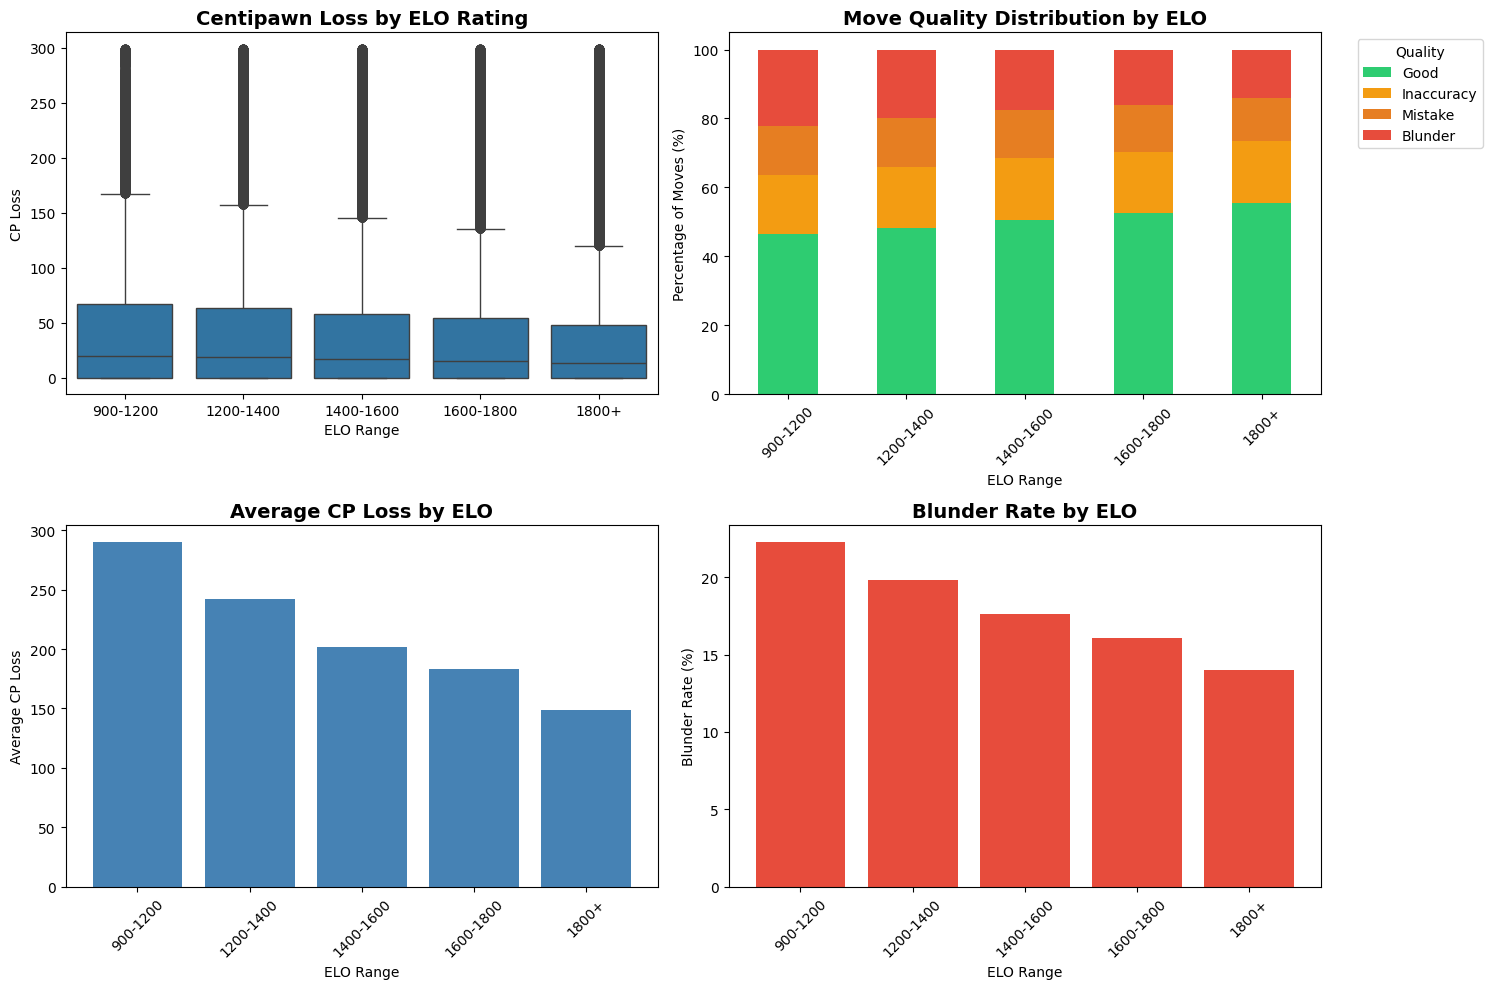


=== SUMMARY STATISTICS ===
Total positions: 312,127
Total games: 4,574

ELO distribution:
elo_bucket
900-1200     27100
1200-1400    52552
1400-1600    68888
1600-1800    70137
1800+        93450
dtype: int64

Overall move quality:
move_quality
Good          51.615849
Inaccuracy    17.858436
Blunder       16.975142
Mistake       13.550574
Name: proportion, dtype: float64


C:\Users\Thanh Tran\AppData\Local\Temp\ipykernel_2388\565723998.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('elo_bucket').size())


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("chess_training_clean_1.parquet")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. CP Loss by ELO
df_plot = df[df['cp_loss'] < 300]  # Cap for better visualization
sns.boxplot(data=df_plot, x='elo_bucket', y='cp_loss', ax=axes[0, 0])
axes[0, 0].set_title('Centipawn Loss by ELO Rating', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('CP Loss')
axes[0, 0].set_xlabel('ELO Range')

# 2. Move quality distribution
quality_pct = pd.crosstab(df['elo_bucket'], df['move_quality'], normalize='index') * 100
quality_pct.plot(kind='bar', stacked=True, ax=axes[0, 1], 
                 color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
axes[0, 1].set_title('Move Quality Distribution by ELO', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Percentage of Moves (%)')
axes[0, 1].set_xlabel('ELO Range')
axes[0, 1].legend(title='Quality', bbox_to_anchor=(1.05, 1))
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)

# 3. Average CP loss
avg_loss = df.groupby('elo_bucket')['cp_loss'].mean()
axes[1, 0].bar(range(len(avg_loss)), avg_loss.values, color='steelblue')
axes[1, 0].set_xticks(range(len(avg_loss)))
axes[1, 0].set_xticklabels(avg_loss.index, rotation=45)
axes[1, 0].set_title('Average CP Loss by ELO', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average CP Loss')
axes[1, 0].set_xlabel('ELO Range')

# 4. Blunder rate
blunder_rate = (df.groupby('elo_bucket')['move_quality'].apply(
    lambda x: (x == 'Blunder').sum() / len(x) * 100
))
axes[1, 1].bar(range(len(blunder_rate)), blunder_rate.values, color='#e74c3c')
axes[1, 1].set_xticks(range(len(blunder_rate)))
axes[1, 1].set_xticklabels(blunder_rate.index, rotation=45)
axes[1, 1].set_title('Blunder Rate by ELO', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Blunder Rate (%)')
axes[1, 1].set_xlabel('ELO Range')

plt.tight_layout()
plt.savefig('move_quality_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Saved move_quality_analysis.png")
plt.show()

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total positions: {len(df):,}")
print(f"Total games: {df['game_id'].nunique():,}")
print(f"\nELO distribution:")
print(df.groupby('elo_bucket').size())
print(f"\nOverall move quality:")
print(df['move_quality'].value_counts(normalize=True) * 100)

=== CP Loss Distribution by ELO ===
cp_loss_bucket    0-5   5-10  10-20  20-30  30-50  50-100  100-200   200+
elo_bucket                                                               
900-1200        11.27   7.47  11.06   9.04  13.32   18.68    14.49  14.66
1200-1400       11.93   8.12  11.96   9.29  13.97   18.71    13.52  12.50
1400-1600       12.58   8.85  12.56   9.93  14.05   18.56    12.63  10.83
1600-1800       13.62   9.34  13.18   9.76  14.30   18.23    11.89   9.68
1800+           14.55  10.27  14.20  10.34  14.24   17.25    10.84   8.32

=== Average CP Loss by Game Phase ===
game_phase  Opening  Middlegame  Endgame
elo_bucket                              
900-1200      71.10      203.70   533.14
1200-1400     46.60      166.44   444.53
1400-1600     35.92      141.00   355.37
1600-1800     32.51      104.69   323.27
1800+         24.76       79.93   257.17

=== CP Loss by Position Complexity ===
complexity_bucket  Equal  Slight_edge  Clear_edge  Winning
elo_bucket           

C:\Users\Thanh Tran\AppData\Local\Temp\ipykernel_2388\3128924985.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_analysis = df.groupby(['elo_bucket', 'game_phase'])['cp_loss'].mean().unstack()
C:\Users\Thanh Tran\AppData\Local\Temp\ipykernel_2388\3128924985.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  complexity_analysis = df.groupby(['elo_bucket', 'complexity_bucket'])['cp_loss'].mean().unstack()



✓ Saved detailed_analysis.png


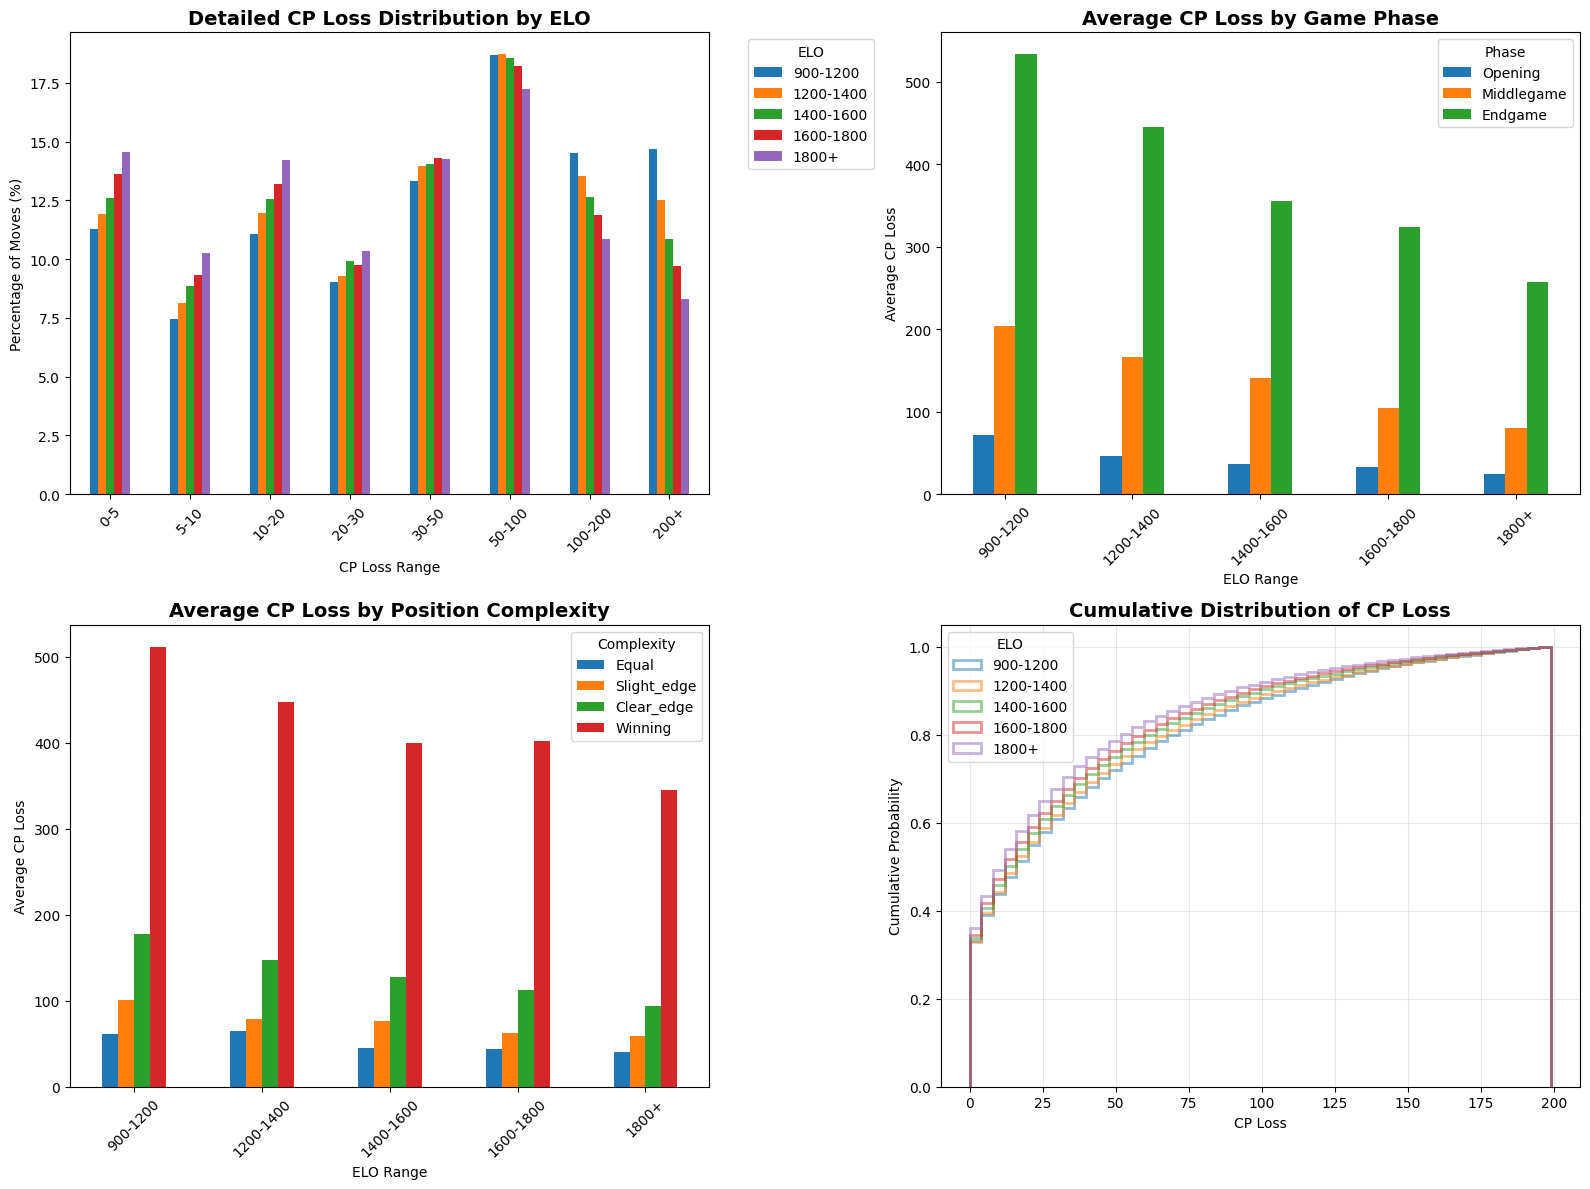

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("chess_training_clean_1.parquet")

# More granular CP loss buckets
df['cp_loss_bucket'] = pd.cut(
    df['cp_loss'],
    bins=[0, 5, 10, 20, 30, 50, 100, 200, float('inf')],
    labels=['0-5', '5-10', '10-20', '20-30', '30-50', '50-100', '100-200', '200+']
)

# Analyze distribution by ELO
print("=== CP Loss Distribution by ELO ===")
cp_dist = pd.crosstab(df['elo_bucket'], df['cp_loss_bucket'], normalize='index') * 100
print(cp_dist.round(2))

# Game phase analysis
df['game_phase'] = pd.cut(
    df['move_number'],
    bins=[0, 15, 40, 200],
    labels=['Opening', 'Middlegame', 'Endgame']
)

print("\n=== Average CP Loss by Game Phase ===")
phase_analysis = df.groupby(['elo_bucket', 'game_phase'])['cp_loss'].mean().unstack()
print(phase_analysis.round(2))

# Position complexity (based on eval magnitude)
df['position_complexity'] = df['eval'].abs()
df['complexity_bucket'] = pd.cut(
    df['position_complexity'],
    bins=[0, 50, 150, 300, float('inf')],
    labels=['Equal', 'Slight_edge', 'Clear_edge', 'Winning']
)

print("\n=== CP Loss by Position Complexity ===")
complexity_analysis = df.groupby(['elo_bucket', 'complexity_bucket'])['cp_loss'].mean().unstack()
print(complexity_analysis.round(2))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Detailed CP loss distribution
cp_dist.T.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Detailed CP Loss Distribution by ELO', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Percentage of Moves (%)')
axes[0, 0].set_xlabel('CP Loss Range')
axes[0, 0].legend(title='ELO', bbox_to_anchor=(1.05, 1))
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# 2. CP loss by game phase
phase_analysis.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average CP Loss by Game Phase', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average CP Loss')
axes[0, 1].set_xlabel('ELO Range')
axes[0, 1].legend(title='Phase')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)

# 3. CP loss by position complexity
complexity_analysis.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Average CP Loss by Position Complexity', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average CP Loss')
axes[1, 0].set_xlabel('ELO Range')
axes[1, 0].legend(title='Complexity')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# 4. Cumulative distribution of CP loss
for elo in df['elo_bucket'].cat.categories:
    subset = df[df['elo_bucket'] == elo]['cp_loss']
    subset_capped = subset[subset < 200]
    axes[1, 1].hist(subset_capped, bins=50, alpha=0.5, label=elo, cumulative=True, 
                    density=True, histtype='step', linewidth=2)

axes[1, 1].set_title('Cumulative Distribution of CP Loss', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('CP Loss')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].legend(title='ELO')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('detailed_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved detailed_analysis.png")
plt.show()

In [39]:
df

,game_id,move_number,is_white,player_elo,fen,move,is_best,cp_loss,eval,eval_after,move_quality,elo_bucket,cp_loss_bucket,game_phase,position_complexity,complexity_bucket
0,0,0,True,1368,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,e2e4,True,5.0,47,42.0,Good,1200-1400,0-5,NaN,47,Equal
1,0,1,False,1409,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,g7g6,False,27.0,42,69.0,Inaccuracy,1400-1600,20-30,Opening,42,Equal
2,0,2,True,1368,rnbqkbnr/pppppp1p/6p1/8/4P3/8/PPPP1PPP/RNBQKBN...,d2d4,True,0.0,69,69.0,Good,1200-1400,NaN,Opening,69,Slight_edge
3,0,3,False,1409,rnbqkbnr/pppppp1p/6p1/8/3PP3/8/PPP2PPP/RNBQKBN...,f8g7,True,8.0,69,77.0,Good,1400-1600,5-10,Opening,69,Slight_edge
4,0,4,True,1368,rnbqk1nr/ppppppbp/6p1/8/3PP3/8/PPP2PPP/RNBQKBN...,e4e5,False,98.0,77,-21.0,Mistake,1200-1400,50-100,Opening,77,Slight_edge
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316695,4573,75,False,1902,8/p3k3/1pp1p3/8/1PPP2rb/6p1/P5K1/3R4 b - - 0 38,a7a6,False,70.0,-542,-472.0,Mistake,1800+,50-100,Endgame,542,Winning
316696,4573,76,True,1918,8/4k3/ppp1p3/8/1PPP2rb/6p1/P5K1/3R4 w - - 0 39,a2a4,False,52.0,-472,-524.0,Mistake,1800+,50-100,Endgame,472,Winning
316697,4573,77,False,1902,8/4k3/ppp1p3/8/PPPP2rb/6p1/6K1/3R4 b - - 0 39,h4g5,False,59.0,-524,-465.0,Mistake,1800+,50-100,Endgame,524,Winning
316698,4573,78,True,1918,8/4k3/ppp1p3/6b1/PPPP2r1/6p1/6K1/3R4 w - - 1 40,g2f3,False,0.0,-465,-458.0,Good,1800+,NaN,Endgame,465,Winning


# Optional: Split to get certain elo range

In [50]:
import pandas as pd
import numpy as np

# Define bin edges
bins = [1000, 1500, 1800, np.inf]

# Define labels
labels = [
    "1200-1500",
    "1500-1800",
    "1800+"
]

# Create new column
df["elo_group"] = pd.cut(
    df["player_elo"],
    bins=bins,
    labels=labels,
    right=False   # left-inclusive: 1200 belongs to 1200-1500
)

print(df["elo_group"].value_counts())

elo_group
1200-1500    111217
1500-1800    106942
1800+         93968
Name: count, dtype: int64


In [52]:
import os

# Define bin edges
bins = [1000, 1500, 1800, np.inf]

# Define labels
labels = [
    "1200-1500",
    "1500-1800",
    "1800+"
]


df["elo_group"] = pd.cut(df["player_elo"], bins=bins, labels=labels, right=False)

# Create output directory
output_dir = "elo_groups"
os.makedirs(output_dir, exist_ok=True)

# Save each group
for group_name, group_df in df.groupby("elo_group"):
    if pd.isna(group_name):
        continue
        
    filename = f"{output_dir}/games_{group_name}.csv"
    group_df.to_csv(filename, index=False)
    print(f"Saved: {filename} ({len(group_df)} rows)")

C:\Users\Thanh Tran\AppData\Local\Temp\ipykernel_2388\2254237912.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in df.groupby("elo_group"):


Saved: elo_groups/games_1200-1500.csv (111217 rows)
Saved: elo_groups/games_1500-1800.csv (106942 rows)
Saved: elo_groups/games_1800+.csv (93968 rows)
